In [2]:
import anndata as ad
import scanpy as sc

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [1]:
from clustering import protein_clustering, cluster_genes

In [5]:
# import preprocessed data
rna_hvg = ad.read_h5ad("../preprocessing/outputs/rna_hvg.h5ad")
pro = ad.read_h5ad("../preprocessing/outputs/protein_data_v2.h5ad")

# Leiden clustering - spatial map, UMAP plot and dot plot

Leiden resolution: 0.5, Number of clusters: 12
Clusters: protein_cluster
3     34847
7     33788
4     28917
5     27401
0     26756
1      9456
10     2172
9       950
11      753
2       589
6       523
8        34
Name: count, dtype: int64


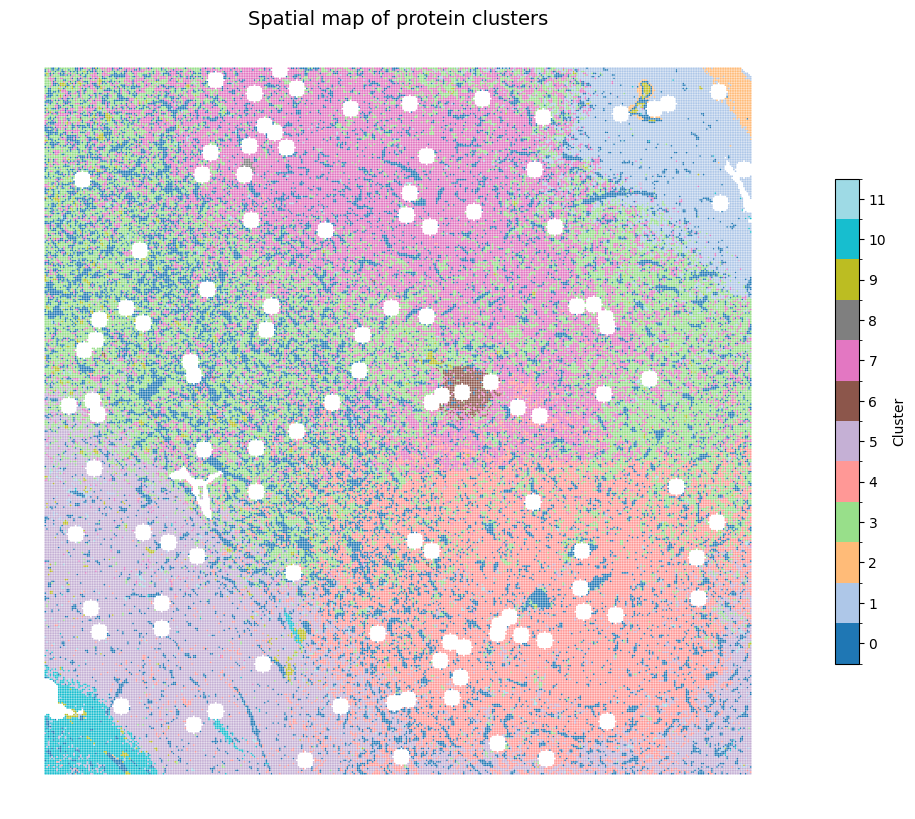

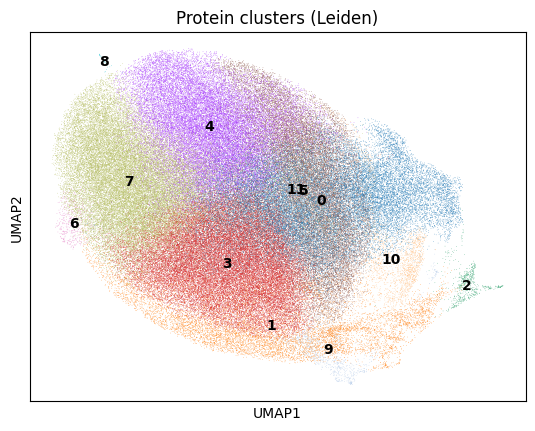

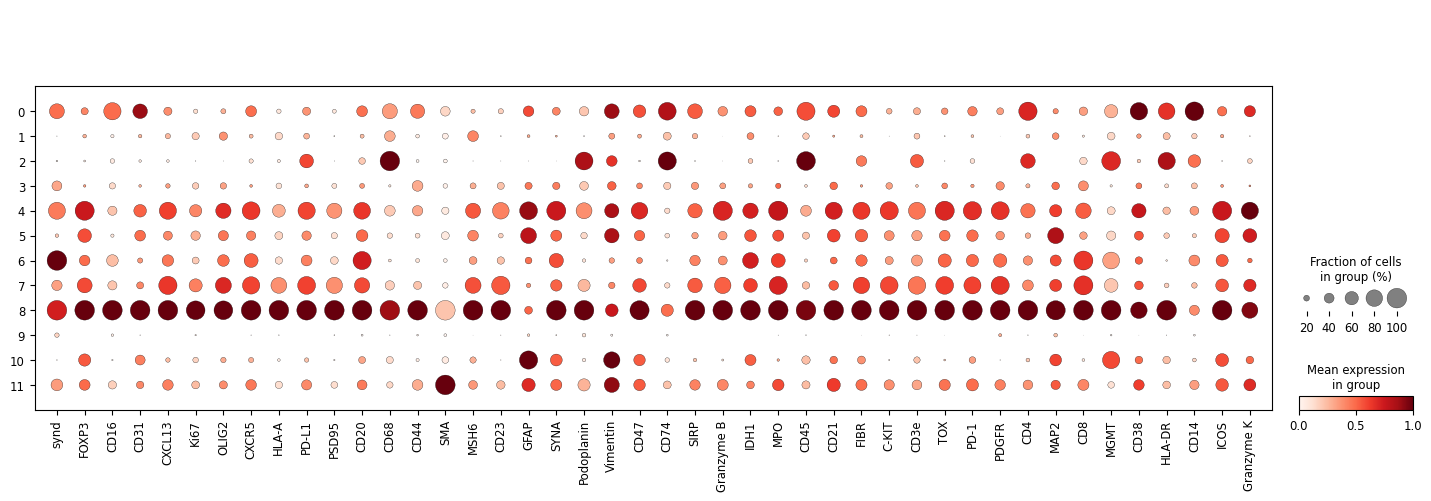

In [6]:
# stage 1
protein_data = protein_clustering(pro, 0.5)

In [7]:
protein_data.write_h5ad("results/pro_cl0.5.h5ad")

# Add cluster labels to RNA, Find marker genes per cluster

In [8]:
# find marker genes
rna_hvg, markers_df = cluster_genes(rna_hvg, protein_data, 5)
markers_df

,cluster,rank,gene,score,log2FC,pval_adj
0,0,1,SELENOP,47.005699,1.5375,0.00e+00
1,0,2,CD74,41.639198,1.1612,0.00e+00
2,0,3,A2M,37.242599,1.3460,9.29e-301
3,0,4,C1QA,22.742201,1.0469,8.56e-112
4,0,5,SLC40A1,21.813200,1.1725,6.96e-103
5,1,1,IGFBP5,21.750799,1.2049,1.36e-101
6,1,2,IGHM,18.773199,4.5395,1.25e-75
7,1,3,EGR1,17.353300,1.5553,1.24e-64
8,1,4,IGKC,16.048401,3.7510,2.93e-55
9,1,5,SOX5,15.966100,1.1166,8.80e-55


In [9]:
# save files
rna_hvg.write_h5ad("results/rna_hvg_cl0.5.h5ad")
markers_df.to_csv("results/genes_cl0.5.csv")